In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

Struktur Folder Dataset

In [2]:
DATA_DIR = Path("../data/raw")

In [3]:
for path in sorted(DATA_DIR.rglob("*")):
    print(path)

..\data\raw\meta_data
..\data\raw\meta_data\households.csv
..\data\raw\meta_data\meta_data.csv
..\data\raw\meta_data\meta_data_variables.csv
..\data\raw\reports
..\data\raw\reports\protocols.csv
..\data\raw\reports\protocols_variables.csv
..\data\raw\smart_meter_data
..\data\raw\smart_meter_data\15min
..\data\raw\smart_meter_data\15min\100101.csv
..\data\raw\smart_meter_data\15min\100105.csv
..\data\raw\smart_meter_data\15min\1001109.csv
..\data\raw\smart_meter_data\15min\1001118.csv
..\data\raw\smart_meter_data\15min\1001121.csv
..\data\raw\smart_meter_data\15min\1001167.csv
..\data\raw\smart_meter_data\15min\1001188.csv
..\data\raw\smart_meter_data\15min\100119.csv
..\data\raw\smart_meter_data\15min\100120.csv
..\data\raw\smart_meter_data\15min\100122.csv
..\data\raw\smart_meter_data\15min\1001228.csv
..\data\raw\smart_meter_data\15min\100167.csv
..\data\raw\smart_meter_data\15min\100211.csv
..\data\raw\smart_meter_data\15min\1006811.csv
..\data\raw\smart_meter_data\15min\1007079.csv

In [4]:
print("Isi data/raw:")
for item in DATA_DIR.iterdir():
    print(item.name)

Isi data/raw:
meta_data
reports
smart_meter_data
weather_data


In [5]:
for folder in DATA_DIR.iterdir():

    if folder.is_dir():

        file_count = len(
            list(folder.rglob("*"))
        )

        print(
            f"{folder.name} : {file_count} items"
        )

meta_data : 3 items
reports : 2 items
smart_meter_data : 5263 items
weather_data : 21 items


# Memahami Smart Meter Dataset

In [6]:
SMART_METER_DIR = (
    DATA_DIR /
    "smart_meter_data" /
    "15min"
)

smart_files = sorted(
    SMART_METER_DIR.glob("*.csv")
)

sample_file = smart_files[0]

print("File contoh:")
print(sample_file.name)

df = pd.read_csv(
    sample_file,
    sep=';'
)

File contoh:
100101.csv


In [7]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape:
(132480, 7)

Columns:
['Household_ID', 'AffectsTimePoint', 'Group', 'Timestamp', 'kWh_received_Total', 'kWh_received_HeatPump', 'kWh_received_Other']

Data Types:
Household_ID               int64
AffectsTimePoint             str
Group                        str
Timestamp                    str
kWh_received_Total       float64
kWh_received_HeatPump    float64
kWh_received_Other       float64
dtype: object


In [8]:
df.head()

,Household_ID,AffectsTimePoint,Group,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other
0,100101,unknown,control,2020-03-08 00:00:00+00:00,0.0,NaN,NaN
1,100101,unknown,control,2020-03-08 00:15:00+00:00,0.0,NaN,NaN
2,100101,unknown,control,2020-03-08 00:30:00+00:00,0.0,NaN,NaN
3,100101,unknown,control,2020-03-08 00:45:00+00:00,0.0,NaN,NaN
4,100101,unknown,control,2020-03-08 01:00:00+00:00,0.0,NaN,NaN


In [9]:
df.tail()

,Household_ID,AffectsTimePoint,Group,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other
132475,100101,unknown,control,2024-02-27 22:45:00+00:00,0.421,NaN,NaN
132476,100101,unknown,control,2024-02-27 23:00:00+00:00,0.172,NaN,NaN
132477,100101,unknown,control,2024-02-27 23:15:00+00:00,0.069,NaN,NaN
132478,100101,unknown,control,2024-02-27 23:30:00+00:00,0.048,NaN,NaN
132479,100101,unknown,control,2024-02-27 23:45:00+00:00,0.068,NaN,NaN


In [10]:
df.describe(include='all')

,Household_ID,AffectsTimePoint,Group,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other
count,132480.0,132480,132480,132480,132480.000000,0.0,0.0
unique,NaN,1,1,132480,NaN,NaN,NaN
top,NaN,unknown,control,2020-03-08 00:00:00+00:00,NaN,NaN,NaN
freq,NaN,132480,132480,1,NaN,NaN,NaN
mean,100101.0,NaN,NaN,NaN,0.153176,NaN,NaN
std,0.0,NaN,NaN,NaN,0.339939,NaN,NaN
min,100101.0,NaN,NaN,NaN,0.000000,NaN,NaN
25%,100101.0,NaN,NaN,NaN,0.000000,NaN,NaN
50%,100101.0,NaN,NaN,NaN,0.048000,NaN,NaN
75%,100101.0,NaN,NaN,NaN,0.151000,NaN,NaN


Memahami Dimensi Waktu (Timestamp) Smart Meter Dataset

In [11]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(df['Timestamp'].dtype)

datetime64[us, UTC]


In [12]:
print("Tanggal Awal :", df['Timestamp'].min())
print("Tanggal Akhir:", df['Timestamp'].max())

Tanggal Awal : 2020-03-08 00:00:00+00:00
Tanggal Akhir: 2024-02-27 23:45:00+00:00


In [13]:
duration = (
    df['Timestamp'].max()
    - df['Timestamp'].min()
)

print("Durasi Observasi:")
print(duration)

Durasi Observasi:
1451 days 23:45:00


In [14]:
print(
    "Jumlah hari:",
    duration.days
)

Jumlah hari: 1451


In [15]:
print(
    "Jumlah tahun:",
    round(duration.days / 365, 2)
)

Jumlah tahun: 3.98


Verifikasi Resolusi Waktu Smart Meter Dataset

In [16]:
time_diff = (
    df['Timestamp']
    .sort_values()
    .diff()
)

time_diff.value_counts().head(20)

Timestamp
0 days 00:15:00     132472
1 days 00:15:00          3
50 days 00:15:00         1
13 days 00:15:00         1
2 days 00:15:00          1
4 days 00:15:00          1
Name: count, dtype: int64

In [17]:
time_diff.describe()

count                    132479
mean     0 days 00:15:46.956876
std      0 days 03:25:16.185808
min             0 days 00:15:00
25%             0 days 00:15:00
50%             0 days 00:15:00
75%             0 days 00:15:00
max            50 days 00:15:00
Name: Timestamp, dtype: object

In [18]:
print(
    "Jumlah interval unik:",
    time_diff.nunique()
)

Jumlah interval unik: 6


In [19]:
print(
    time_diff
    .value_counts()
    .sort_index()
)

Timestamp
0 days 00:15:00     132472
1 days 00:15:00          3
2 days 00:15:00          1
4 days 00:15:00          1
13 days 00:15:00         1
50 days 00:15:00         1
Name: count, dtype: int64


Mencari Lokasi Gap Smart Meter Dataset

In [20]:
gaps = df.loc[
    time_diff > pd.Timedelta(minutes=15),
    ['Timestamp']
].copy()

gaps['gap_size'] = time_diff[
    time_diff > pd.Timedelta(minutes=15)
]

gaps

,Timestamp,gap_size
63936,2022-02-22 00:00:00+00:00,50 days 00:15:00
64704,2022-03-15 00:00:00+00:00,13 days 00:15:00
86688,2022-10-31 00:00:00+00:00,1 days 00:15:00
89952,2022-12-06 00:00:00+00:00,2 days 00:15:00
90816,2022-12-19 00:00:00+00:00,4 days 00:15:00
91584,2022-12-28 00:00:00+00:00,1 days 00:15:00
120864,2023-10-30 00:00:00+00:00,1 days 00:15:00


In [21]:
print(
    f"Jumlah gap: {len(gaps)}"
)

gaps

Jumlah gap: 7


,Timestamp,gap_size
63936,2022-02-22 00:00:00+00:00,50 days 00:15:00
64704,2022-03-15 00:00:00+00:00,13 days 00:15:00
86688,2022-10-31 00:00:00+00:00,1 days 00:15:00
89952,2022-12-06 00:00:00+00:00,2 days 00:15:00
90816,2022-12-19 00:00:00+00:00,4 days 00:15:00
91584,2022-12-28 00:00:00+00:00,1 days 00:15:00
120864,2023-10-30 00:00:00+00:00,1 days 00:15:00


Analisis Missing Value Smart Meter Dataset

In [22]:
df.isnull().sum()

Household_ID                  0
AffectsTimePoint              0
Group                         0
Timestamp                     0
kWh_received_Total            0
kWh_received_HeatPump    132480
kWh_received_Other       132480
dtype: int64

In [23]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (
        df.isnull().mean() * 100
    ).round(2)
})

missing

,missing_count,missing_percent
Household_ID,0,0.0
AffectsTimePoint,0,0.0
Group,0,0.0
Timestamp,0,0.0
kWh_received_Total,0,0.0
kWh_received_HeatPump,132480,100.0
kWh_received_Other,132480,100.0


In [24]:
missing.sort_values(
    by='missing_percent',
    ascending=False
)

,missing_count,missing_percent
kWh_received_HeatPump,132480,100.0
kWh_received_Other,132480,100.0
Household_ID,0,0.0
AffectsTimePoint,0,0.0
Group,0,0.0
Timestamp,0,0.0
kWh_received_Total,0,0.0


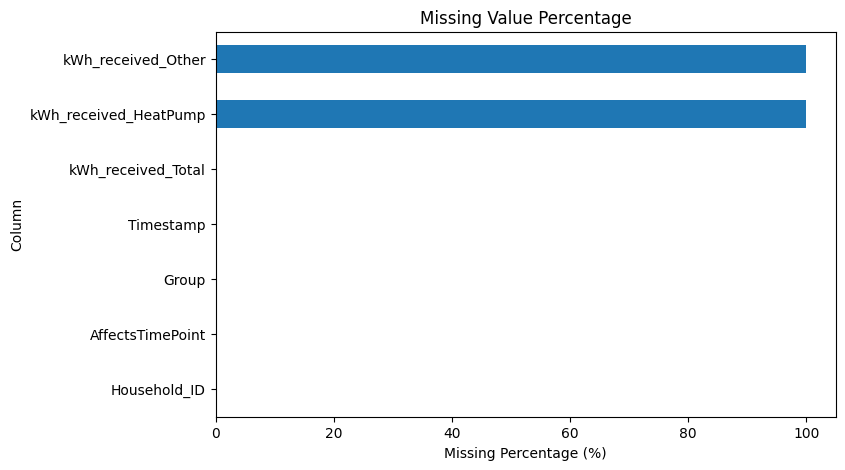

In [25]:
import matplotlib.pyplot as plt

missing.sort_values(
    by='missing_percent'
)['missing_percent'].plot(
    kind='barh',
    figsize=(8,5)
)

plt.xlabel('Missing Percentage (%)')
plt.ylabel('Column')
plt.title('Missing Value Percentage')
plt.show()

Duplicate Check Smart Meter Dataset

In [27]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [26]:
print(
    "Duplicate timestamp:",
    df['Timestamp'].duplicated().sum()
)

Duplicate timestamp: 0


Distribusi Target Smart Meter Dataset

In [28]:
df['kWh_received_Total'].describe()

count    132480.000000
mean          0.153176
std           0.339939
min           0.000000
25%           0.000000
50%           0.048000
75%           0.151000
max           5.423000
Name: kWh_received_Total, dtype: float64

In [29]:
print(
    "Jumlah nilai nol:",
    (df['kWh_received_Total'] == 0).sum()
)

print(
    "Persentase nilai nol:",
    round(
        (
            df['kWh_received_Total'] == 0
        ).mean() * 100,
        2
    ),
    "%"
)

Jumlah nilai nol: 35660
Persentase nilai nol: 26.92 %


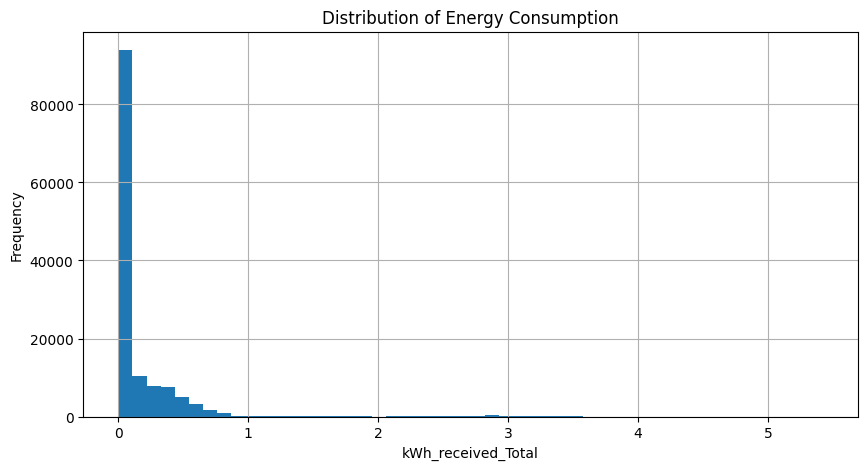

In [30]:
import matplotlib.pyplot as plt

df['kWh_received_Total'].hist(
    bins=50,
    figsize=(10,5)
)

plt.title(
    'Distribution of Energy Consumption'
)

plt.xlabel(
    'kWh_received_Total'
)

plt.ylabel(
    'Frequency'
)

plt.show()

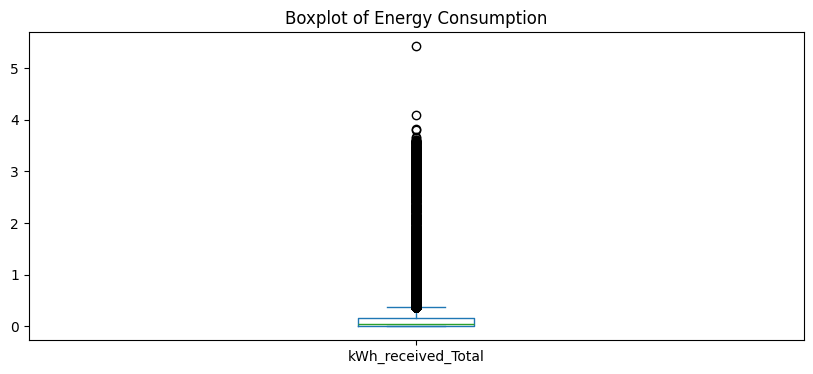

In [31]:
df['kWh_received_Total'].plot.box(
    figsize=(10,4)
)

plt.title(
    'Boxplot of Energy Consumption'
)

plt.show()

Visualisasi Time Series

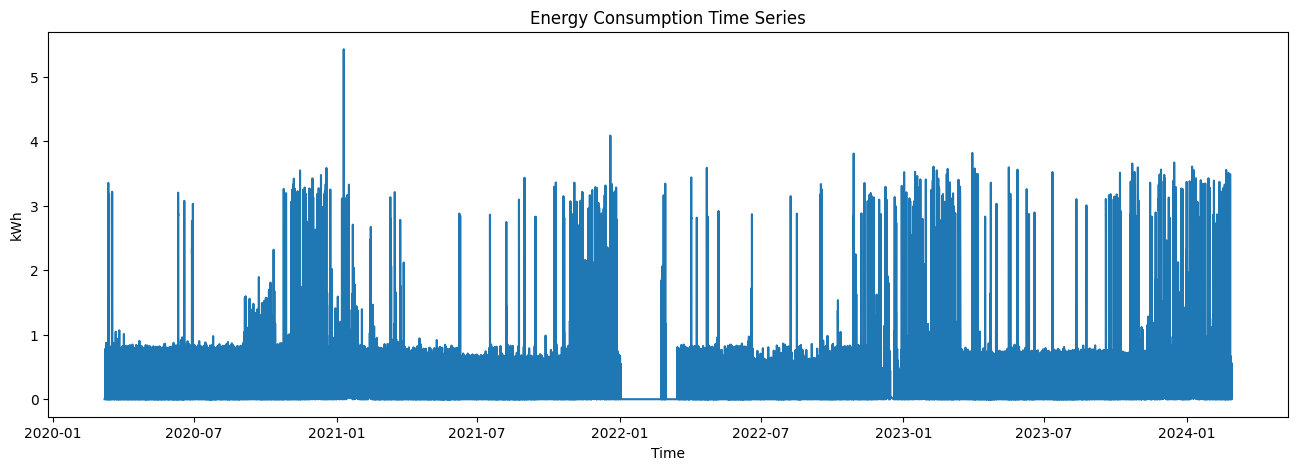

In [32]:
df = df.sort_values('Timestamp')

plt.figure(figsize=(16,5))

plt.plot(
    df['Timestamp'],
    df['kWh_received_Total']
)

plt.title(
    'Energy Consumption Time Series'
)

plt.xlabel('Time')
plt.ylabel('kWh')

plt.show()

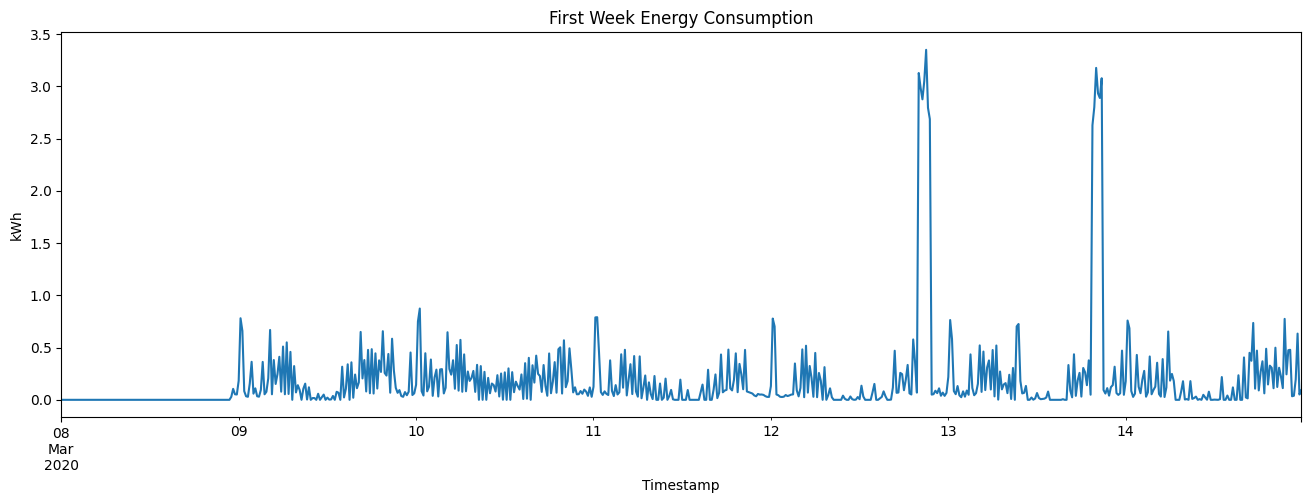

In [33]:
sample_week = (
    df
    .set_index('Timestamp')
    ['kWh_received_Total']
    .iloc[:96*7]
)

plt.figure(figsize=(16,5))

sample_week.plot()

plt.title(
    'First Week Energy Consumption'
)

plt.ylabel('kWh')

plt.show()

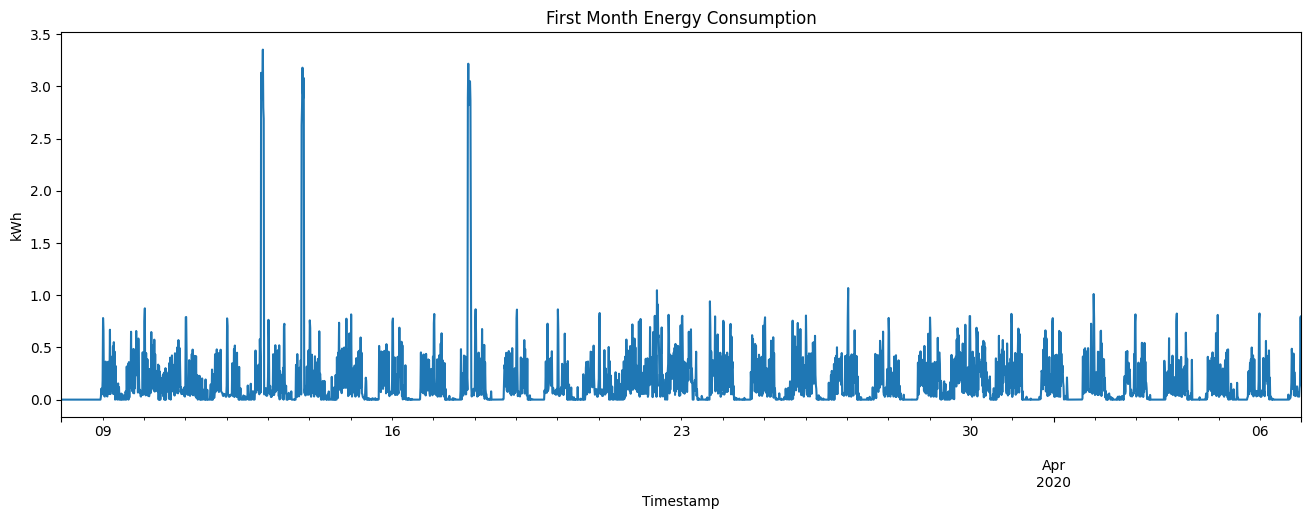

In [34]:
sample_month = (
    df
    .set_index('Timestamp')
    ['kWh_received_Total']
    .iloc[:96*30]
)

plt.figure(figsize=(16,5))

sample_month.plot()

plt.title(
    'First Month Energy Consumption'
)

plt.ylabel('kWh')

plt.show()

# Memahami Metadata Dataset

In [35]:
META_DIR = DATA_DIR / "meta_data"

meta_files = sorted(
    META_DIR.glob("*.csv")
)

print("Jumlah file metadata:", len(meta_files))

for file in meta_files:
    print(file.name)

Jumlah file metadata: 3
households.csv
meta_data.csv
meta_data_variables.csv


In [38]:
for file in meta_files:
    print("="*60)
    print(file.name)

    temp = pd.read_csv(file, sep=';')

    print("Shape :", temp.shape)
    print(temp.head())
    print()

households.csv
Shape : (1408, 11)
   Household_ID      Group Weather_ID Installation_HasPVSystem  \
0        661091  treatment        MqO                    False   
1        120701  treatment         Hg                     True   
2        412211  treatment         Hg                    False   
3        706646  treatment        8jB                      NaN   
4       1078861  treatment        8jB                     True   

   Protocols_Available  Protocols_HasMultipleVisits Protocols_ReportIDs  \
0                 True                        False                [29]   
1                 True                        False                [32]   
2                 True                        False                [40]   
3                 True                        False               [137]   
4                 True                        False               [138]   

   MetaData_Available  SmartMeterData_Available_15min  \
0                True                            True   
1   

In [40]:
for file in meta_files:

    temp = pd.read_csv(file, sep=';')

    print("="*60)
    print(file.name)

    print(temp.columns.tolist())
    print()

households.csv
['Household_ID', 'Group', 'Weather_ID', 'Installation_HasPVSystem', 'Protocols_Available', 'Protocols_HasMultipleVisits', 'Protocols_ReportIDs', 'MetaData_Available', 'SmartMeterData_Available_15min', 'SmartMeterData_Available_Daily', 'SmartMeterData_Available_Monthly']

meta_data.csv
['Household_ID', 'Survey_Building_Type', 'Survey_Building_LivingArea', 'Survey_Building_Residents', 'Survey_HeatPump_Installation_Type', 'Survey_HeatDistribution_System_FloorHeating', 'Survey_HeatDistribution_System_Radiator', 'Survey_DHW_Production_ByHeatPump', 'Survey_DHW_Production_ByElectricWaterHeater', 'Survey_DHW_Production_BySolar', 'Survey_Installation_HasDryer', 'Survey_Installation_HasFreezer', 'Survey_Installation_HasElectricVehicle']

meta_data_variables.csv
['VariableName', 'Description']



Analisis Metadata Lebih Dalam

In [41]:
meta_df = pd.read_csv(
    META_DIR / "meta_data.csv",
    sep=';'
)

meta_df.head()

,Household_ID,Survey_Building_Type,Survey_Building_LivingArea,Survey_Building_Residents,Survey_HeatPump_Installation_Type,Survey_HeatDistribution_System_FloorHeating,Survey_HeatDistribution_System_Radiator,Survey_DHW_Production_ByHeatPump,Survey_DHW_Production_ByElectricWaterHeater,Survey_DHW_Production_BySolar,Survey_Installation_HasDryer,Survey_Installation_HasFreezer,Survey_Installation_HasElectricVehicle
0,86109,house,150.0,2.0,air-source,NaN,NaN,NaN,True,NaN,False,True,True
1,100119,house,130.0,3.0,ground-source,True,False,NaN,True,NaN,True,True,NaN
2,100120,house,130.0,2.0,air-source,False,True,True,NaN,NaN,False,True,NaN
3,103721,house,160.0,2.0,ground-source,True,False,True,NaN,NaN,True,True,NaN
4,104118,house,155.0,3.0,ground-source,True,False,NaN,True,NaN,True,True,NaN


In [42]:
meta_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 13 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Household_ID                                 1358 non-null   int64  
 1   Survey_Building_Type                         1356 non-null   str    
 2   Survey_Building_LivingArea                   1339 non-null   float64
 3   Survey_Building_Residents                    1348 non-null   float64
 4   Survey_HeatPump_Installation_Type            1354 non-null   str    
 5   Survey_HeatDistribution_System_FloorHeating  1310 non-null   object 
 6   Survey_HeatDistribution_System_Radiator      1310 non-null   object 
 7   Survey_DHW_Production_ByHeatPump             851 non-null    object 
 8   Survey_DHW_Production_ByElectricWaterHeater  424 non-null    object 
 9   Survey_DHW_Production_BySolar                70 non-null     object 
 10  Survey_Inst

In [43]:
meta_missing = pd.DataFrame({
    'missing_count': meta_df.isnull().sum(),
    'missing_percent':
        (meta_df.isnull().mean()*100).round(2)
})

meta_missing.sort_values(
    by='missing_percent',
    ascending=False
)

,missing_count,missing_percent
Survey_DHW_Production_BySolar,1288,94.85
Survey_DHW_Production_ByElectricWaterHeater,934,68.78
Survey_DHW_Production_ByHeatPump,507,37.33
Survey_Installation_HasElectricVehicle,171,12.59
Survey_HeatDistribution_System_FloorHeating,48,3.53
Survey_HeatDistribution_System_Radiator,48,3.53
Survey_Building_LivingArea,19,1.40
Survey_Building_Residents,10,0.74
Survey_Installation_HasDryer,9,0.66
Survey_Installation_HasFreezer,9,0.66


In [44]:
meta_df.describe()

,Household_ID,Survey_Building_LivingArea,Survey_Building_Residents
count,1.358000e+03,1339.000000,1348.000000
mean,2.155706e+06,193.283794,2.871662
std,2.962641e+06,71.649653,1.098963
min,1.060000e+03,36.000000,1.000000
25%,4.119102e+05,150.000000,2.000000
50%,8.193525e+05,180.000000,2.000000
75%,1.186350e+06,220.000000,4.000000
max,9.981041e+06,1116.000000,7.000000


In [45]:
for col in meta_df.columns:

    if meta_df[col].dtype == 'object':

        print("="*50)
        print(col)
        print(meta_df[col].value_counts(dropna=False))

Survey_HeatDistribution_System_FloorHeating
Survey_HeatDistribution_System_FloorHeating
True     1062
False     248
NaN        48
Name: count, dtype: int64
Survey_HeatDistribution_System_Radiator
Survey_HeatDistribution_System_Radiator
False    916
True     394
NaN       48
Name: count, dtype: int64
Survey_DHW_Production_ByHeatPump
Survey_DHW_Production_ByHeatPump
True    851
NaN     507
Name: count, dtype: int64
Survey_DHW_Production_ByElectricWaterHeater
Survey_DHW_Production_ByElectricWaterHeater
NaN     934
True    424
Name: count, dtype: int64
Survey_DHW_Production_BySolar
Survey_DHW_Production_BySolar
NaN     1288
True      70
Name: count, dtype: int64
Survey_Installation_HasDryer
Survey_Installation_HasDryer
True     1081
False     268
NaN         9
Name: count, dtype: int64
Survey_Installation_HasFreezer
Survey_Installation_HasFreezer
True     1233
False     116
NaN         9
Name: count, dtype: int64
Survey_Installation_HasElectricVehicle
Survey_Installation_HasElectricVehicle

Memahami Data Dictionary (meta_data_variables.csv)

In [46]:
meta_var = pd.read_csv(
    META_DIR / "meta_data_variables.csv",
    sep=';'
)

meta_var.head()

,VariableName,Description
0,Household_ID,unique household identifier
1,Survey_Building_Type,"type of building (house, appartment) - as decl..."
2,Survey_Building_LivingArea,living area of building (in square meters) - a...
3,Survey_Building_Residents,number of household residents - as declared by...
4,Survey_HeatPump_Installation_Type,"heat pump type (air-source, ground-source) - a..."


In [47]:
pd.set_option('display.max_colwidth', None)

meta_var

,VariableName,Description
0,Household_ID,unique household identifier
1,Survey_Building_Type,"type of building (house, appartment) - as declared by household in online tool"
2,Survey_Building_LivingArea,living area of building (in square meters) - as declared by household in online tool
3,Survey_Building_Residents,number of household residents - as declared by household in online tool
4,Survey_HeatPump_Installation_Type,"heat pump type (air-source, ground-source) - as declared by household in online tool"
5,Survey_HeatDistribution_System_FloorHeating,indication if heat is distributed by floor heating - as declared by household in online tool
6,Survey_HeatDistribution_System_Radiator,indication if heat is distributed by radiator - as declared by household in online tool
7,Survey_DHW_Production_ByHeatPump,indication if domestic hot water is produced by the heat pump - as declared by household in online tool
8,Survey_DHW_Production_ByElectricWaterHeater,indication if domestic hot water is produced by electric water heater - as declared by household in online tool
9,Survey_DHW_Production_BySolar,indication if domestic hot water is produced by solar collector - as declared by household in online tool


In [49]:
for _, row in meta_var.iterrows():
    print("="*80)
    print("Variable :", row['VariableName'])
    print("Description :", row['Description'])
    print()

Variable : Household_ID
Description : unique household identifier

Variable : Survey_Building_Type
Description : type of building (house, appartment) - as declared by household in online tool

Variable : Survey_Building_LivingArea
Description : living area of building (in square meters) - as declared by household in online tool

Variable : Survey_Building_Residents
Description : number of household residents - as declared by household in online tool

Variable : Survey_HeatPump_Installation_Type
Description : heat pump type (air-source, ground-source) - as declared by household in online tool

Variable : Survey_HeatDistribution_System_FloorHeating
Description : indication if heat is distributed by floor heating - as declared by household in online tool

Variable : Survey_HeatDistribution_System_Radiator
Description : indication if heat is distributed by radiator - as declared by household in online tool

Variable : Survey_DHW_Production_ByHeatPump
Description : indication if domestic ho

Membuka households.csv

In [50]:
households_df = pd.read_csv(
    META_DIR / "households.csv",
    sep=';'
)

households_df.head()

,Household_ID,Group,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,SmartMeterData_Available_Monthly
0,661091,treatment,MqO,False,True,False,[29],True,True,True,True
1,120701,treatment,Hg,True,True,False,[32],True,True,True,True
2,412211,treatment,Hg,False,True,False,[40],True,True,True,True
3,706646,treatment,8jB,NaN,True,False,[137],False,True,False,False
4,1078861,treatment,8jB,True,True,False,[138],True,True,True,True


In [51]:
households_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1408 entries, 0 to 1407
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Household_ID                      1408 non-null   int64 
 1   Group                             1408 non-null   str   
 2   Weather_ID                        1408 non-null   str   
 3   Installation_HasPVSystem          650 non-null    object
 4   Protocols_Available               1408 non-null   bool  
 5   Protocols_HasMultipleVisits       1408 non-null   bool  
 6   Protocols_ReportIDs               214 non-null    str   
 7   MetaData_Available                1408 non-null   bool  
 8   SmartMeterData_Available_15min    1408 non-null   bool  
 9   SmartMeterData_Available_Daily    1408 non-null   bool  
 10  SmartMeterData_Available_Monthly  1408 non-null   bool  
dtypes: bool(6), int64(1), object(1), str(3)
memory usage: 78.6+ KB


In [52]:
households_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1408 entries, 0 to 1407
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Household_ID                      1408 non-null   int64 
 1   Group                             1408 non-null   str   
 2   Weather_ID                        1408 non-null   str   
 3   Installation_HasPVSystem          650 non-null    object
 4   Protocols_Available               1408 non-null   bool  
 5   Protocols_HasMultipleVisits       1408 non-null   bool  
 6   Protocols_ReportIDs               214 non-null    str   
 7   MetaData_Available                1408 non-null   bool  
 8   SmartMeterData_Available_15min    1408 non-null   bool  
 9   SmartMeterData_Available_Daily    1408 non-null   bool  
 10  SmartMeterData_Available_Monthly  1408 non-null   bool  
dtypes: bool(6), int64(1), object(1), str(3)
memory usage: 78.6+ KB


In [53]:
household_missing = pd.DataFrame({
    'missing_count':
        households_df.isnull().sum(),
    'missing_percent':
        (households_df.isnull().mean()*100).round(2)
})

household_missing.sort_values(
    by='missing_percent',
    ascending=False
)

,missing_count,missing_percent
Protocols_ReportIDs,1194,84.80
Installation_HasPVSystem,758,53.84
Household_ID,0,0.00
Group,0,0.00
Weather_ID,0,0.00
Protocols_Available,0,0.00
Protocols_HasMultipleVisits,0,0.00
MetaData_Available,0,0.00
SmartMeterData_Available_15min,0,0.00
SmartMeterData_Available_Daily,0,0.00


In [54]:
for col in households_df.columns:

    if households_df[col].dtype == 'object':

        print("="*60)
        print(col)
        print(
            households_df[col]
            .value_counts(dropna=False)
        )

Installation_HasPVSystem
Installation_HasPVSystem
NaN      758
True     516
False    134
Name: count, dtype: int64


In [55]:
for col in households_df.columns:

    if (
        households_df[col].dtype == 'bool'
        or
        households_df[col].dtype == 'object'
    ):

        print("="*60)
        print(col)
        print(
            households_df[col]
            .value_counts(dropna=False)
        )

Installation_HasPVSystem
Installation_HasPVSystem
NaN      758
True     516
False    134
Name: count, dtype: int64
Protocols_Available
Protocols_Available
False    1194
True      214
Name: count, dtype: int64
Protocols_HasMultipleVisits
Protocols_HasMultipleVisits
False    1405
True        3
Name: count, dtype: int64
MetaData_Available
MetaData_Available
True     1358
False      50
Name: count, dtype: int64
SmartMeterData_Available_15min
SmartMeterData_Available_15min
True     1407
False       1
Name: count, dtype: int64
SmartMeterData_Available_Daily
SmartMeterData_Available_Daily
True     1298
False     110
Name: count, dtype: int64
SmartMeterData_Available_Monthly
SmartMeterData_Available_Monthly
True     1264
False     144
Name: count, dtype: int64


# Memahami Weather Dataset

In [56]:
WEATHER_DIR = DATA_DIR / "weather_data"

for path in sorted(WEATHER_DIR.rglob("*")):
    print(path)

..\data\raw\weather_data\daily
..\data\raw\weather_data\daily\8jB.csv
..\data\raw\weather_data\daily\ceOxS.csv
..\data\raw\weather_data\daily\HbsbG.csv
..\data\raw\weather_data\daily\Hg.csv
..\data\raw\weather_data\daily\MqO.csv
..\data\raw\weather_data\daily\sV3mR.csv
..\data\raw\weather_data\daily\wDD.csv
..\data\raw\weather_data\daily\z6I.csv
..\data\raw\weather_data\hourly
..\data\raw\weather_data\hourly\8jB.csv
..\data\raw\weather_data\hourly\ceOxS.csv
..\data\raw\weather_data\hourly\HbsbG.csv
..\data\raw\weather_data\hourly\Hg.csv
..\data\raw\weather_data\hourly\MqO.csv
..\data\raw\weather_data\hourly\sV3mR.csv
..\data\raw\weather_data\hourly\wDD.csv
..\data\raw\weather_data\hourly\z6I.csv
..\data\raw\weather_data\overview
..\data\raw\weather_data\overview\weather_variables.csv
..\data\raw\weather_data\overview\weather_variables_availability.csv


In [57]:
WEATHER_HOURLY_DIR = (
    WEATHER_DIR / "hourly"
)

weather_files = sorted(
    WEATHER_HOURLY_DIR.glob("*.csv")
)

print(
    "Jumlah file weather:",
    len(weather_files)
)

for f in weather_files[:10]:
    print(f.name)

Jumlah file weather: 8
8jB.csv
ceOxS.csv
HbsbG.csv
Hg.csv
MqO.csv
sV3mR.csv
wDD.csv
z6I.csv


In [58]:
sample_weather = weather_files[0]

print(
    "File contoh:",
    sample_weather.name
)

weather_df = pd.read_csv(
    sample_weather,
    sep=';'
)

weather_df.head()

File contoh: 8jB.csv


,Weather_ID,Timestamp,Temperature_avg_hourly,DewPoint_hourly,Humidity_avg_hourly,Precipitation_total_hourly,Pressure_BarometricHeight_avg_hourly,Pressure_SeaLevelStandardAtmosphere_avg_hourly,Pressure_SeaLevel_avg_hourly,Sunshine_duration_hourly,WindSpeed_hourly
0,8jB,2019-01-01 00:00:00+00:00,4.8,3.7,91.9,0.0,982.4,1033.6,1035.0,0.0,1.1
1,8jB,2019-01-01 01:00:00+00:00,4.5,3.4,93.5,0.0,982.6,1033.8,1035.2,0.0,1.3
2,8jB,2019-01-01 02:00:00+00:00,4.3,3.5,94.8,0.0,982.8,1034.0,1035.5,0.0,0.9
3,8jB,2019-01-01 03:00:00+00:00,4.2,3.4,95.1,0.0,982.5,1033.7,1035.2,0.0,1.7
4,8jB,2019-01-01 04:00:00+00:00,4.2,3.0,93.5,0.0,981.6,1032.7,1034.3,0.0,1.6


In [59]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45264 entries, 0 to 45263
Data columns (total 11 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Weather_ID                                      45264 non-null  str    
 1   Timestamp                                       45264 non-null  str    
 2   Temperature_avg_hourly                          45264 non-null  float64
 3   DewPoint_hourly                                 45264 non-null  float64
 4   Humidity_avg_hourly                             45264 non-null  float64
 5   Precipitation_total_hourly                      45263 non-null  float64
 6   Pressure_BarometricHeight_avg_hourly            45264 non-null  float64
 7   Pressure_SeaLevelStandardAtmosphere_avg_hourly  45264 non-null  float64
 8   Pressure_SeaLevel_avg_hourly                    45264 non-null  float64
 9   Sunshine_duration_hourly                        45

In [60]:
weather_df.columns.tolist()

['Weather_ID',
 'Timestamp',
 'Temperature_avg_hourly',
 'DewPoint_hourly',
 'Humidity_avg_hourly',
 'Precipitation_total_hourly',
 'Pressure_BarometricHeight_avg_hourly',
 'Pressure_SeaLevelStandardAtmosphere_avg_hourly',
 'Pressure_SeaLevel_avg_hourly',
 'Sunshine_duration_hourly',
 'WindSpeed_hourly']

In [61]:
weather_missing = pd.DataFrame({
    'missing_count':
        weather_df.isnull().sum(),
    'missing_percent':
        (
            weather_df.isnull().mean()
            * 100
        ).round(2)
})

weather_missing.sort_values(
    by='missing_percent',
    ascending=False
)

,missing_count,missing_percent
WindSpeed_hourly,160,0.35
Weather_ID,0,0.00
Timestamp,0,0.00
Temperature_avg_hourly,0,0.00
DewPoint_hourly,0,0.00
Humidity_avg_hourly,0,0.00
Precipitation_total_hourly,1,0.00
Pressure_BarometricHeight_avg_hourly,0,0.00
Pressure_SeaLevelStandardAtmosphere_avg_hourly,0,0.00
Pressure_SeaLevel_avg_hourly,0,0.00


Memahami Time Series Weather

In [62]:
weather_df['Timestamp'] = pd.to_datetime(
    weather_df['Timestamp']
)

print(
    weather_df['Timestamp'].dtype
)

datetime64[us, UTC]


In [63]:
print(
    "Tanggal awal:",
    weather_df['Timestamp'].min()
)

print(
    "Tanggal akhir:",
    weather_df['Timestamp'].max()
)

Tanggal awal: 2019-01-01 00:00:00+00:00
Tanggal akhir: 2024-02-29 23:00:00+00:00


In [64]:
duration = (
    weather_df['Timestamp'].max()
    -
    weather_df['Timestamp'].min()
)

print(duration)

1885 days 23:00:00


In [65]:
weather_diff = (
    weather_df['Timestamp']
    .sort_values()
    .diff()
)

weather_diff.value_counts()

Timestamp
0 days 01:00:00    45263
Name: count, dtype: int64

In [66]:
weather_diff.nunique()

1

In [68]:
weather_gaps = weather_df.loc[
    weather_diff >
    pd.Timedelta(hours=1),
    ['Timestamp']
].copy()

weather_gaps['gap_size'] = weather_diff[
    weather_diff >
    pd.Timedelta(hours=1)
]

weather_gaps

,Timestamp,gap_size


# Memahami Reports Dataset

In [69]:
REPORT_DIR = DATA_DIR / "reports"

report_files = sorted(
    REPORT_DIR.glob("*.csv")
)

print("Jumlah file:", len(report_files))

for f in report_files:
    print(f.name)

Jumlah file: 2
protocols.csv
protocols_variables.csv


In [70]:
for f in report_files:

    print("="*70)
    print(f.name)

    temp = pd.read_csv(
        f,
        sep=';'
    )

    print("Shape:", temp.shape)
    print(temp.head())
    print()

protocols.csv
Shape: (410, 106)
   Report_ID  Household_ID  Visit_Year Visit_Date        Building_Type  \
0          0           NaN        2015        NaN   multi family house   
1          1           NaN        2015        NaN  single family house   
2          2           NaN        2015        NaN  single family house   
3          3           NaN        2015        NaN  single family house   
4          4           NaN        2015        NaN  single family house   

   Building_HousingUnits  Building_ConstructionYear  \
0                    3.0                        NaN   
1                    NaN                     1982.0   
2                    NaN                     1999.0   
3                    NaN                     1989.0   
4                    NaN                     1904.0   

  Building_ConstructionYear_Interval  Building_Renovated_Windows  \
0                          1976 - 80                       False   
1                          1981 - 85                    

In [71]:
for f in report_files:

    temp = pd.read_csv(
        f,
        sep=';'
    )

    print("="*70)
    print(f.name)

    print(temp.columns.tolist())
    print()

protocols.csv
['Report_ID', 'Household_ID', 'Visit_Year', 'Visit_Date', 'Building_Type', 'Building_HousingUnits', 'Building_ConstructionYear', 'Building_ConstructionYear_Interval', 'Building_Renovated_Windows', 'Building_Renovated_Roof', 'Building_Renovated_Walls', 'Building_Renovated_Floor', 'Building_FloorAreaHeated_Total', 'Building_FloorAreaHeated_Basement', 'Building_FloorAreaHeated_GroundFloor', 'Building_FloorAreaHeated_FirstFloor', 'Building_FloorAreaHeated_SecondFloor', 'Building_FloorAreaHeated_TopFloor', 'Building_FloorAreaHeated_AdditionalAreasPlanned', 'Building_FloorAreaHeated_AdditionalAreasPlannedSize', 'Building_Residents', 'Building_PVSystem_Available', 'Building_PVSystem_Size', 'Building_ElectricVehicle_Available', 'HeatPump_Installation_Type', 'HeatPump_Installation_Year', 'HeatPump_Installation_Manufacturer', 'HeatPump_Installation_Model', 'HeatPump_Installation_HeatingCapacity', 'HeatPump_Installation_Refrigerant_Type', 'HeatPump_Installation_Refrigerant_Content',

Kesimpulan Tahap Data Understanding

Pada tahap data understanding, dilakukan proses identifikasi dan eksplorasi terhadap seluruh sumber data yang digunakan dalam penelitian, yaitu data smart meter, data cuaca (weather), metadata rumah tangga, dan data protokol inspeksi (protocol reports). Tahap ini bertujuan untuk memahami karakteristik, struktur, kualitas, serta keterkaitan antar dataset sebelum dilakukan proses integrasi dan pemodelan.

Berdasarkan hasil eksplorasi, dataset smart meter terdiri dari 1.407 file yang merepresentasikan masing-masing rumah tangga (household) dengan resolusi data 15 menit. Setiap file berisi data konsumsi energi listrik dengan variabel utama yaitu kWh_received_Total yang akan digunakan sebagai target prediksi. Data smart meter memiliki rentang waktu yang cukup panjang, yaitu hampir empat tahun, dengan mayoritas interval pengukuran bersifat kontinu setiap 15 menit. Namun, ditemukan beberapa gap observasi pada sebagian household yang menunjukkan karakteristik data dunia nyata (real-world dataset). Selain itu, tidak ditemukan missing value pada variabel target, tidak terdapat data duplikat, dan distribusi konsumsi energi menunjukkan pola yang tidak normal (right-skewed) dengan sekitar 26,92% observasi bernilai nol serta terdapat beberapa nilai ekstrem (outlier). Visualisasi time series menunjukkan adanya pola musiman (seasonality) harian dan mingguan yang berpotensi dimanfaatkan melalui feature engineering berbasis waktu.

Eksplorasi metadata menunjukkan bahwa dataset meta_data.csv terdiri dari 1.358 rumah tangga dengan 13 variabel yang mendeskripsikan karakteristik bangunan dan penghuni rumah, seperti tipe bangunan, luas bangunan, jumlah penghuni, jenis heat pump, keberadaan kendaraan listrik, dan sistem pemanas. Sebagian besar variabel memiliki tingkat kelengkapan data yang tinggi sehingga berpotensi digunakan sebagai fitur tambahan (static features) dalam model prediksi. Variabel-variabel tersebut dinilai relevan karena dapat membantu model memahami perbedaan karakteristik antar rumah tangga pada pendekatan global forecasting.

Selanjutnya, dataset cuaca (weather dataset) terdiri dari delapan stasiun cuaca yang diidentifikasi melalui Weather_ID. Data cuaca memiliki resolusi waktu satu jam dengan rentang observasi lebih dari lima tahun dan tidak ditemukan gap pada urutan waktunya. Variabel cuaca yang tersedia meliputi temperatur, kelembaban, titik embun, curah hujan, tekanan udara, durasi penyinaran matahari, dan kecepatan angin. Kualitas data cuaca tergolong sangat baik karena memiliki tingkat missing value yang sangat rendah, sehingga sangat layak digunakan sebagai fitur eksogen dalam proses prediksi konsumsi energi.

Selain itu, dilakukan eksplorasi terhadap dataset protocols.csv yang berisi hasil inspeksi lapangan dan informasi teknis mengenai sistem pemanas dan bangunan. Dataset ini memiliki 106 variabel, namun hanya mencakup sekitar 214 rumah tangga. Karena cakupan datanya relatif kecil dibandingkan keseluruhan dataset, penggunaan data protokol berpotensi mengurangi jumlah rumah tangga yang dapat digunakan dalam pemodelan global. Oleh karena itu, dataset protokol tidak digunakan pada model utama dan hanya dipertimbangkan sebagai informasi tambahan atau untuk penelitian lanjutan.

Berdasarkan keseluruhan proses data understanding, dapat disimpulkan bahwa dataset HEAPO memiliki karakteristik sebagai dataset time series multivariat, multi-household, dan multi-source yang sangat sesuai untuk penelitian prediksi konsumsi energi berbasis machine learning. Ketersediaan data konsumsi energi, data cuaca, dan metadata rumah tangga memberikan peluang untuk membangun model global multi-household forecasting yang mampu mempelajari pola konsumsi energi dari berbagai karakteristik rumah tangga dan faktor lingkungan. Hasil tahap data understanding ini menjadi dasar dalam proses integrasi data, pemilihan household yang memenuhi kriteria penelitian, serta pembentukan fitur pada tahap selanjutnya.

# Household Selection dan Preliminary Data Integration

Membuat Master Household Table

In [72]:
master_household = households_df.copy()

master_household.head()

,Household_ID,Group,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,SmartMeterData_Available_Monthly
0,661091,treatment,MqO,False,True,False,[29],True,True,True,True
1,120701,treatment,Hg,True,True,False,[32],True,True,True,True
2,412211,treatment,Hg,False,True,False,[40],True,True,True,True
3,706646,treatment,8jB,NaN,True,False,[137],False,True,False,False
4,1078861,treatment,8jB,True,True,False,[138],True,True,True,True


In [73]:
master_household.shape

(1408, 11)

In [74]:
master_household.info()

<class 'pandas.DataFrame'>
RangeIndex: 1408 entries, 0 to 1407
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Household_ID                      1408 non-null   int64 
 1   Group                             1408 non-null   str   
 2   Weather_ID                        1408 non-null   str   
 3   Installation_HasPVSystem          650 non-null    object
 4   Protocols_Available               1408 non-null   bool  
 5   Protocols_HasMultipleVisits       1408 non-null   bool  
 6   Protocols_ReportIDs               214 non-null    str   
 7   MetaData_Available                1408 non-null   bool  
 8   SmartMeterData_Available_15min    1408 non-null   bool  
 9   SmartMeterData_Available_Daily    1408 non-null   bool  
 10  SmartMeterData_Available_Monthly  1408 non-null   bool  
dtypes: bool(6), int64(1), object(1), str(3)
memory usage: 78.6+ KB


Profiling Seluruh Household

In [75]:
from tqdm import tqdm

household_profiles = []

for file in tqdm(smart_files):

    temp = pd.read_csv(
        file,
        sep=';'
    )

    temp['Timestamp'] = pd.to_datetime(
        temp['Timestamp']
    )

    household_id = temp['Household_ID'].iloc[0]

    start_date = temp['Timestamp'].min()
    end_date = temp['Timestamp'].max()

    duration_days = (
        end_date - start_date
    ).days

    n_rows = len(temp)

    missing_target = (
        temp['kWh_received_Total']
        .isna()
        .sum()
    )

    zero_ratio = (
        (temp['kWh_received_Total'] == 0)
        .mean()
        * 100
    )

    household_profiles.append({
        'Household_ID': household_id,
        'n_rows': n_rows,
        'start_date': start_date,
        'end_date': end_date,
        'duration_days': duration_days,
        'missing_target': missing_target,
        'zero_ratio': zero_ratio
    })

household_profiles = pd.DataFrame(
    household_profiles
)

household_profiles.head()

100%|██████████| 1407/1407 [02:52<00:00,  8.14it/s]


,Household_ID,n_rows,start_date,end_date,duration_days,missing_target,zero_ratio
0,100101,132480,2020-03-08 00:00:00+00:00,2024-02-27 23:45:00+00:00,1451,0,26.917271
1,100105,34464,2023-02-25 00:00:00+00:00,2024-02-27 23:45:00+00:00,367,0,20.517061
2,1001109,41856,2022-04-28 00:00:00+00:00,2023-07-08 23:45:00+00:00,436,0,0.219801
3,1001118,87840,2021-08-25 00:00:00+00:00,2024-02-27 23:45:00+00:00,916,0,0.416667
4,1001121,108288,2021-01-21 00:00:00+00:00,2024-02-27 23:45:00+00:00,1132,72960,0.000000


In [76]:
household_profiles.shape

(1407, 7)

In [77]:
household_profiles.describe()

,Household_ID,n_rows,duration_days,missing_target,zero_ratio
count,1.407000e+03,1407.000000,1407.000000,1407.000000,1407.000000
mean,2.161256e+06,61319.982942,675.332623,1673.211087,6.097138
std,2.962124e+06,30319.477641,316.385124,11447.135915,9.393531
min,1.060000e+03,1920.000000,19.000000,0.000000,0.000000
25%,4.120105e+05,41040.000000,447.000000,0.000000,0.160561
50%,8.188820e+05,53664.000000,597.000000,0.000000,0.339147
75%,1.189859e+06,72480.000000,810.000000,0.000000,11.202816
max,9.981041e+06,160800.000000,1744.000000,131904.000000,67.930927


In [78]:
household_profiles.sort_values(
    by='duration_days',
    ascending=False
).head(10)

,Household_ID,n_rows,start_date,end_date,duration_days,missing_target,zero_ratio
317,1137376,160800,2019-05-20 00:00:00+00:00,2024-02-27 23:45:00+00:00,1744,0,0.360697
485,121728,149760,2019-11-03 00:00:00+00:00,2024-02-27 23:45:00+00:00,1577,0,0.122196
1214,86109,138624,2019-11-04 00:00:00+00:00,2024-02-27 23:45:00+00:00,1576,0,2.021295
308,112996,147936,2019-11-04 00:00:00+00:00,2024-02-27 23:45:00+00:00,1576,0,27.801211
1394,991816,148800,2019-11-11 00:00:00+00:00,2024-02-27 23:45:00+00:00,1569,0,18.137769
1237,868122,147360,2019-11-12 00:00:00+00:00,2024-02-27 23:45:00+00:00,1568,0,0.565282
562,411389,112416,2019-11-12 00:00:00+00:00,2024-02-27 23:45:00+00:00,1568,56352,0.088066
1390,991118,150432,2019-11-12 00:00:00+00:00,2024-02-27 23:45:00+00:00,1568,0,0.130956
1352,971071,150240,2019-11-14 00:00:00+00:00,2024-02-27 23:45:00+00:00,1566,0,0.250266
1128,823761,148608,2019-11-16 00:00:00+00:00,2024-02-27 23:45:00+00:00,1564,0,0.495263


In [79]:
household_profiles.sort_values(
    by='duration_days'
).head(10)

,Household_ID,n_rows,start_date,end_date,duration_days,missing_target,zero_ratio
1262,877881,1920,2024-02-08 00:00:00+00:00,2024-02-27 23:45:00+00:00,19,0,4.791667
621,468665,2496,2021-07-22 00:00:00+00:00,2021-08-16 23:45:00+00:00,25,0,0.000000
312,113115,4032,2024-01-17 00:00:00+00:00,2024-02-27 23:45:00+00:00,41,1152,0.173611
902,731027,4608,2024-01-11 00:00:00+00:00,2024-02-27 23:45:00+00:00,47,0,10.286458
443,119701,4896,2024-01-08 00:00:00+00:00,2024-02-27 23:45:00+00:00,50,0,1.879085
568,412211,6240,2023-12-25 00:00:00+00:00,2024-02-27 23:45:00+00:00,64,0,1.474359
469,120912,6336,2019-11-12 00:00:00+00:00,2020-01-16 23:45:00+00:00,65,0,1.704545
962,758039,6720,2023-12-20 00:00:00+00:00,2024-02-27 23:45:00+00:00,69,0,1.428571
1330,9073879,9600,2023-11-20 00:00:00+00:00,2024-02-27 23:45:00+00:00,99,0,1.000000
775,688105,8640,2023-11-14 00:00:00+00:00,2024-02-27 23:45:00+00:00,105,0,14.386574


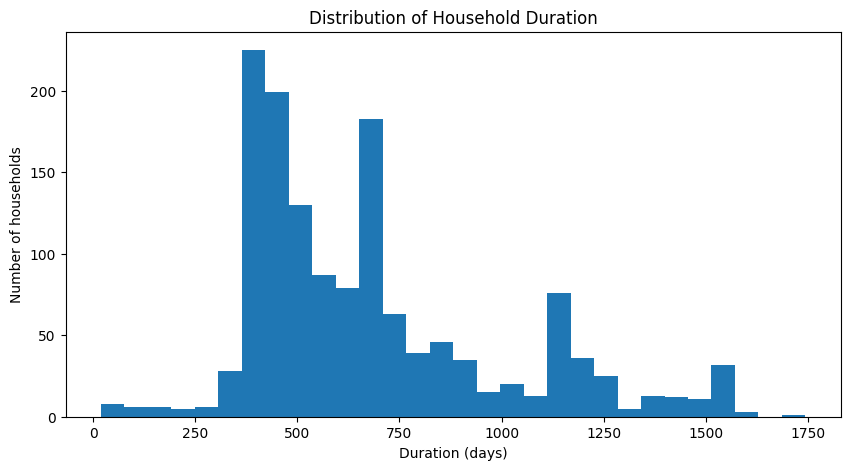

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    household_profiles['duration_days'],
    bins=30
)

plt.xlabel('Duration (days)')
plt.ylabel('Number of households')
plt.title('Distribution of Household Duration')

plt.show()

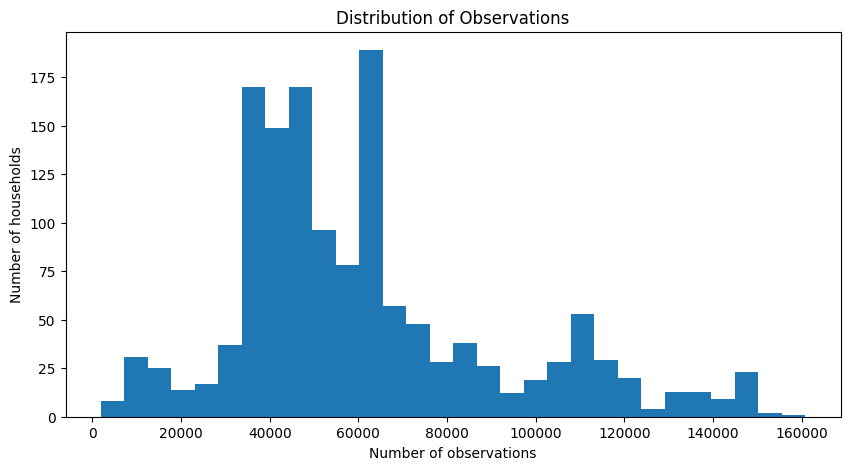

In [81]:
plt.figure(figsize=(10,5))

plt.hist(
    household_profiles['n_rows'],
    bins=30
)

plt.xlabel('Number of observations')
plt.ylabel('Number of households')
plt.title('Distribution of Observations')

plt.show()

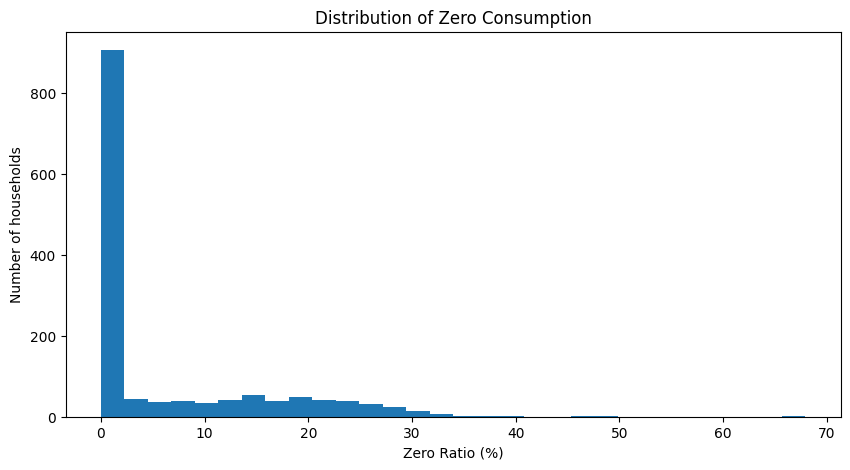

In [82]:
plt.figure(figsize=(10,5))

plt.hist(
    household_profiles['zero_ratio'],
    bins=30
)

plt.xlabel('Zero Ratio (%)')
plt.ylabel('Number of households')
plt.title('Distribution of Zero Consumption')

plt.show()

In [83]:
master_household = master_household.merge(
    household_profiles,
    on='Household_ID',
    how='left'
)

In [84]:
master_household.shape

(1408, 17)

In [85]:
master_household.head()

,Household_ID,Group,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,SmartMeterData_Available_Monthly,n_rows,start_date,end_date,duration_days,missing_target,zero_ratio
0,661091,treatment,MqO,False,True,False,[29],True,True,True,True,65568.0,2022-04-14 00:00:00+00:00,2024-02-27 23:45:00+00:00,684.0,0.0,0.013726
1,120701,treatment,Hg,True,True,False,[32],True,True,True,True,54912.0,2022-07-20 00:00:00+00:00,2024-02-27 23:45:00+00:00,587.0,0.0,1.249272
2,412211,treatment,Hg,False,True,False,[40],True,True,True,True,6240.0,2023-12-25 00:00:00+00:00,2024-02-27 23:45:00+00:00,64.0,0.0,1.474359
3,706646,treatment,8jB,NaN,True,False,[137],False,True,False,False,89760.0,2021-08-03 00:00:00+00:00,2024-02-27 23:45:00+00:00,938.0,0.0,18.875891
4,1078861,treatment,8jB,True,True,False,[138],True,True,True,True,38304.0,2022-03-12 00:00:00+00:00,2023-10-12 23:45:00+00:00,579.0,0.0,31.435359


In [86]:
master_household[
    [
        'Household_ID',
        'duration_days',
        'missing_target',
        'zero_ratio',
        'MetaData_Available',
        'Weather_ID'
    ]
].head()

,Household_ID,duration_days,missing_target,zero_ratio,MetaData_Available,Weather_ID
0,661091,684.0,0.0,0.013726,True,MqO
1,120701,587.0,0.0,1.249272,True,Hg
2,412211,64.0,0.0,1.474359,True,Hg
3,706646,938.0,0.0,18.875891,False,8jB
4,1078861,579.0,0.0,31.435359,True,8jB


In [87]:
candidate_households = master_household[
    (
        master_household[
            'duration_days'
        ] >= 365
    )
    &
    (
        master_household[
            'MetaData_Available'
        ] == True
    )
    &
    (
        master_household[
            'SmartMeterData_Available_15min'
        ] == True
    )
]

In [88]:
candidate_households.shape

(1296, 17)

In [89]:
candidate_households[
    [
        'duration_days',
        'missing_target',
        'zero_ratio'
    ]
].describe()

,duration_days,missing_target,zero_ratio
count,1296.000000,1296.000000,1296.000000
mean,692.328704,1474.666667,5.945554
std,308.391675,10932.049561,9.315291
min,365.000000,0.000000,0.000000
25%,456.750000,0.000000,0.157265
50%,622.500000,0.000000,0.313424
75%,832.250000,0.000000,10.407765
max,1744.000000,131904.000000,67.930927


In [ ]:
master_household['missing_ratio'] = (
    master_household['missing_target']
    /
    master_household['n_rows']
) * 100

In [92]:
master_household[
    [
        'missing_ratio',
        'zero_ratio'
    ]
].describe()

,missing_ratio,zero_ratio
count,1407.000000,1407.000000
mean,1.943940,6.097138
std,12.714157,9.393531
min,0.000000,0.000000
25%,0.000000,0.160561
50%,0.000000,0.339147
75%,0.000000,11.202816
max,100.000000,67.930927


In [98]:
candidate_households = master_household[
    (
        master_household['duration_days'] >= 365
    )
    &
    (
        master_household['MetaData_Available'] == True
    )
    &
    (
        master_household['SmartMeterData_Available_15min'] == True
    )
]

In [99]:
candidate_households.columns

Index(['Household_ID', 'Group', 'Weather_ID', 'Installation_HasPVSystem',
       'Protocols_Available', 'Protocols_HasMultipleVisits',
       'Protocols_ReportIDs', 'MetaData_Available',
       'SmartMeterData_Available_15min', 'SmartMeterData_Available_Daily',
       'SmartMeterData_Available_Monthly', 'n_rows', 'start_date', 'end_date',
       'duration_days', 'missing_target', 'zero_ratio', 'missing_ratio'],
      dtype='str')

In [100]:
candidate_households = candidate_households[
    (
        candidate_households['missing_ratio']
        <= 5
    )
    &
    (
        candidate_households['zero_ratio']
        <= 30
    )
]

In [101]:
candidate_households.shape

(1243, 18)

In [102]:
candidate_households[
    [
        'duration_days',
        'missing_ratio',
        'zero_ratio'
    ]
].describe()

,duration_days,missing_ratio,zero_ratio
count,1243.000000,1243.000000,1243.000000
mean,685.765084,0.021277,5.544984
std,306.676026,0.187521,8.467006
min,365.000000,0.000000,0.000000
25%,455.000000,0.000000,0.164919
50%,610.000000,0.000000,0.316456
75%,810.000000,0.000000,9.769946
max,1744.000000,2.672606,29.630545


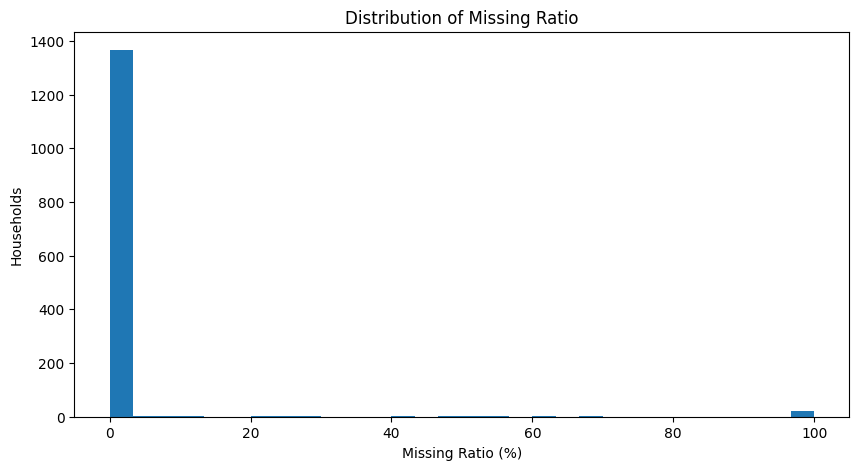

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(
    master_household['missing_ratio'],
    bins=30
)

plt.xlabel('Missing Ratio (%)')
plt.ylabel('Households')
plt.title('Distribution of Missing Ratio')

plt.show()

In [105]:
from sklearn.preprocessing import MinMaxScaler

In [106]:
ranking_df = candidate_households.copy()

In [107]:
scaler = MinMaxScaler()

ranking_df['duration_score'] = scaler.fit_transform(
    ranking_df[['duration_days']]
)

In [108]:
ranking_df['missing_score'] = (
    1 -
    scaler.fit_transform(
        ranking_df[['missing_ratio']]
    )
)

In [109]:
ranking_df['zero_score'] = (
    1 -
    scaler.fit_transform(
        ranking_df[['zero_ratio']]
    )
)

In [110]:
ranking_df['final_score'] = (
      0.5 * ranking_df['duration_score']
    + 0.3 * ranking_df['missing_score']
    + 0.2 * ranking_df['zero_score']
)

In [111]:
ranking_df = ranking_df.sort_values(
    by='final_score',
    ascending=False
)

In [112]:
ranking_df[
    [
        'Household_ID',
        'duration_days',
        'missing_ratio',
        'zero_ratio',
        'final_score'
    ]
].head(20)

,Household_ID,duration_days,missing_ratio,zero_ratio,final_score
18,1137376,1744.0,0.0,0.360697,0.997565
92,121728,1577.0,0.0,0.122196,0.938624
122,991118,1568.0,0.0,0.130956,0.935302
91,971071,1566.0,0.0,0.250266,0.933771
71,868122,1568.0,0.0,0.565282,0.932370
100,823761,1564.0,0.0,0.495263,0.931392
30,781007,1561.0,0.0,0.353710,0.931260
77,111119,1561.0,0.0,0.368082,0.931163
28,468185,1560.0,0.0,0.393891,0.930626
97,7411010,1552.0,0.0,0.075220,0.929877


In [113]:
selected_households = ranking_df.head(
    300
).copy()

In [114]:
selected_households.shape

(300, 22)

In [115]:
selected_households[
    [
        'duration_days',
        'missing_ratio',
        'zero_ratio'
    ]
].describe()

,duration_days,missing_ratio,zero_ratio
count,300.00000,300.000000,300.000000
mean,1137.68000,0.006103,3.429513
std,240.27268,0.063626,6.590687
min,737.00000,0.000000,0.000000
25%,922.75000,0.000000,0.119780
50%,1141.50000,0.000000,0.306075
75%,1244.00000,0.000000,1.858920
max,1744.00000,0.974314,27.801211


In [116]:
selected_ids = (
    selected_households['Household_ID']
    .tolist()
)

len(selected_ids)

300

In [117]:
selected_households.to_csv(
    "../data/processed/selected_households.csv",
    index=False
)

In [118]:
selected_households[
    [
        'Household_ID',
        'duration_days',
        'missing_ratio',
        'zero_ratio',
        'final_score'
    ]
].head(20)

,Household_ID,duration_days,missing_ratio,zero_ratio,final_score
18,1137376,1744.0,0.0,0.360697,0.997565
92,121728,1577.0,0.0,0.122196,0.938624
122,991118,1568.0,0.0,0.130956,0.935302
91,971071,1566.0,0.0,0.250266,0.933771
71,868122,1568.0,0.0,0.565282,0.932370
100,823761,1564.0,0.0,0.495263,0.931392
30,781007,1561.0,0.0,0.353710,0.931260
77,111119,1561.0,0.0,0.368082,0.931163
28,468185,1560.0,0.0,0.393891,0.930626
97,7411010,1552.0,0.0,0.075220,0.929877


Kesimpulan Tahap Data Understanding dan Strategi Integrasi Data

Tahap data understanding dilakukan untuk memahami karakteristik, kualitas, dan hubungan antar dataset yang digunakan dalam penelitian. Berdasarkan hasil eksplorasi, dataset penelitian terdiri atas empat sumber data utama, yaitu data konsumsi energi smart meter dengan resolusi 15 menit, data cuaca dengan resolusi satu jam, metadata rumah tangga hasil survei, dan data protocol hasil kunjungan teknisi. Hasil analisis menunjukkan bahwa data smart meter memiliki jumlah observasi yang sangat besar dengan periode pengamatan yang bervariasi antar rumah tangga, mulai dari beberapa minggu hingga hampir lima tahun. Selain itu, ditemukan perbedaan tingkat kelengkapan data, adanya gap observasi pada beberapa rumah, serta distribusi konsumsi energi yang cenderung tidak simetris (highly skewed) dengan keberadaan beberapa nilai ekstrem. Data cuaca menunjukkan kualitas yang sangat baik karena memiliki interval waktu yang konsisten, cakupan waktu yang panjang, serta tingkat missing value yang sangat rendah. Sementara itu, metadata rumah tangga memiliki informasi penting mengenai karakteristik bangunan dan penghuni, seperti luas bangunan, jumlah penghuni, jenis heat pump, keberadaan kendaraan listrik, dan sistem pemanas, yang berpotensi memengaruhi pola konsumsi energi.

Berdasarkan hasil evaluasi kualitas data, dilakukan proses seleksi untuk memperoleh sampel penelitian yang memiliki kualitas terbaik. Sebanyak 300 rumah tangga dipilih berdasarkan beberapa kriteria, yaitu memiliki data smart meter 15 menit yang tersedia, metadata rumah tangga yang lengkap, periode observasi yang panjang, rasio data hilang yang sangat rendah, serta proporsi konsumsi nol yang relatif kecil. Hasil seleksi ini menghasilkan dataset yang representatif dan berkualitas tinggi untuk mendukung pembangunan model prediksi konsumsi energi berbasis global multi-household dan multi-source time series forecasting.

Pada tahap integrasi data, tidak seluruh dataset digabungkan secara langsung. Penelitian ini hanya mengintegrasikan tiga sumber data utama, yaitu data smart meter, metadata rumah tangga, dan data cuaca. Data smart meter digunakan sebagai sumber variabel target berupa konsumsi energi listrik (kWh_received_Total) sekaligus menjadi sumber pembentukan fitur temporal, seperti jam, hari, bulan, pola musiman, lag features, dan rolling statistics. Metadata rumah tangga diintegrasikan sebagai fitur statis (static features) yang menjelaskan karakteristik masing-masing rumah, sehingga model dapat mempelajari perbedaan pola konsumsi antar rumah tangga. Sementara itu, data cuaca digunakan sebagai fitur eksternal (exogenous features) karena kondisi meteorologi, seperti temperatur, kelembapan, curah hujan, dan kecepatan angin, memiliki hubungan yang kuat dengan kebutuhan pemanasan dan konsumsi energi, terutama pada rumah yang menggunakan sistem heat pump.

Sebaliknya, dataset protocol tidak diintegrasikan pada tahap awal penelitian. Hal ini disebabkan oleh jumlah observasinya yang relatif sedikit dibandingkan jumlah rumah tangga yang tersedia, cakupan datanya yang rendah, serta sifat datanya yang berbasis kejadian (event-based) dan bukan time series kontinu. Selain itu, banyak variabel pada dataset protocol memiliki tingkat missing value yang tinggi sehingga berpotensi mengurangi jumlah sampel yang dapat digunakan dan meningkatkan kompleksitas proses preprocessing. Oleh karena itu, dataset protocol tidak digunakan dalam pembangunan model utama, namun tetap dipertahankan sebagai sumber informasi yang berpotensi dimanfaatkan pada penelitian lanjutan, seperti analisis dampak intervensi teknisi, evaluasi efisiensi sistem heat pump, maupun analisis kausal terhadap perubahan konsumsi energi.

Dengan demikian, strategi integrasi data pada penelitian ini difokuskan pada penggabungan data smart meter, metadata rumah tangga, dan data cuaca karena ketiga sumber data tersebut memiliki cakupan observasi yang tinggi, kualitas data yang baik, serta hubungan langsung terhadap perilaku konsumsi energi. Pendekatan ini diharapkan mampu menghasilkan dataset terpadu yang kuat dan representatif untuk membangun model prediksi konsumsi energi berbasis global multi-household multi-source forecasting dengan tingkat akurasi dan generalisasi yang tinggi.